# Prueba - Reducción de dimensionalidad aplicada a modelos predictivos

En el presente notebook se realiza la prueba, evaluación e implementación de técnicas de PCA y t-SNE sobre un conjunto de datos de estudiantes.

## Preparación y Escalamiento de Datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 1. Datos simulados (multivariable) ---
data = {
    'Edad': [21, 35, 27, 40, 29, 50, 33, 45, 31, 22],
    'Horas_estudio': [5, 10, 6, 8, 7, 11, 9, 4, 7, 5],
    'Evaluaciones_aprobadas': [2, 5, 3, 4, 3, 6, 5, 2, 4, 3],
    'Participacion_foro': [3, 9, 4, 7, 5, 10, 8, 2, 6, 3],
    'Tareas_entregadas': [4, 10, 6, 8, 6, 12, 9, 3, 7, 4]
}
df = pd.DataFrame(data)
display(df.head())

# --- 2. Escalamiento ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

,Edad,Horas_estudio,Evaluaciones_aprobadas,Participacion_foro,Tareas_entregadas
0,21,5,2,3,4
1,35,10,5,9,10
2,27,6,3,4,6
3,40,8,4,7,8
4,29,7,3,5,6


## Requerimiento 1: Aplicación de PCA

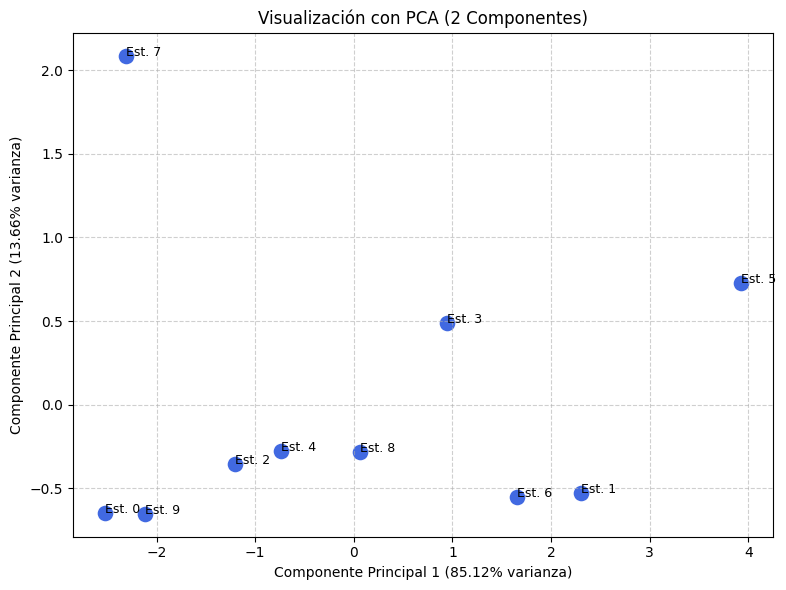

In [30]:
# --- 3. Aplicación de PCA ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], s=150, color='royalblue')

# Índices de los estudiantes para visualización
for i in range(len(X_pca)):
    plt.text(X_pca[i, 0], X_pca[i, 1], f"Est. {i}", fontsize=9)

plt.title('Visualización con PCA (2 Componentes)')
plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]:.2%} varianza)')
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]:.2%} varianza)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [31]:
# --- 5. Exportar datos procesados (opcional) ---
df_pca = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
df_tsne = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])

print("\n🔍 Componentes PCA:")
print(df_pca.head())

print("\n🔍 Coordenadas t-SNE:")
print(df_tsne.head())


🔍 Componentes PCA:
       PCA1      PCA2
0 -2.527404 -0.648754
1  2.302661 -0.525895
2 -1.202393 -0.353793
3  0.940777  0.486845
4 -0.733799 -0.280273

🔍 Coordenadas t-SNE:
       TSNE1       TSNE2
0 -22.536335   48.063519
1  59.701752 -115.112190
2   0.008592    0.367880
3  -2.684195  -83.074181
4  48.111725   -4.586785


### Reflexión sobre los patrones emergentes (PCA)
Al reducir la dimensionalidad a 2 componentes principales, se observa que:
- El **Componente Principal 1** captura la mayoría de la varianza del set de datos. Este eje representa el **rendimiento académico general e involucramiento**, ya que las variables como horas de estudio, participaciones y evaluaciones poseen una correlación positiva.
- **Patrones:** Se observan clústeres o agrupamientos claros. Hacia la derecha del gráfico se observa a los estudiantes de "alto rendimiento" como el Estudiante 1 y 5. Hacia el centro y la izquierda se agrupan los estudiantes con rendimientos intermedios y bajo como, por ejemplo, los estudiante 0 y 7. La proyección aísla perfectamente el comportamiento en un plano 2D lineal.

## Requerimiento 2: Aplicación de t-SNE

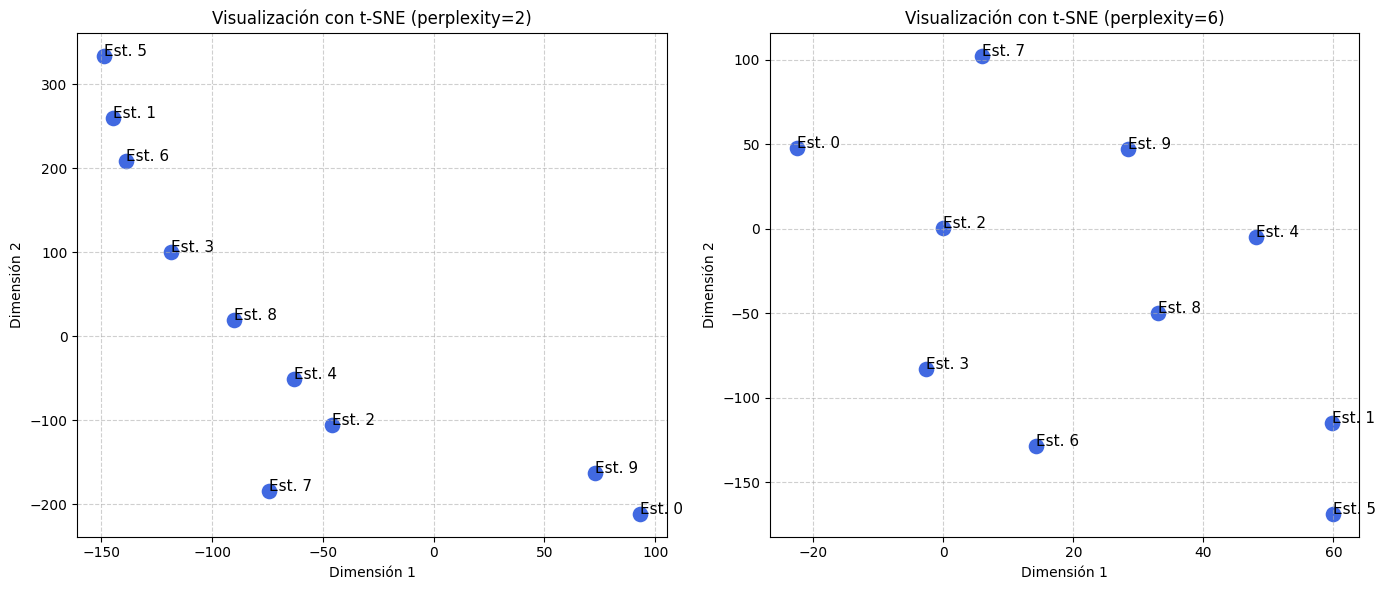

In [32]:
# --- 4. Aplicación de t-SNE ---
# Se evalúan 2 valores distintos (2 y 6) debido al bajo número de muestras.

perplexities = [2, 6]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, p in enumerate(perplexities):
    tsne = TSNE(n_components=2, perplexity=p, random_state=42)
    X_tsne = tsne.fit_transform(X_scaled)
    
    sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], s=150, ax=axes[idx], color='royalblue')
    
    for i in range(len(X_tsne)):
        axes[idx].text(X_tsne[i, 0], X_tsne[i, 1], f"Est. {i}", fontsize=11)
        
    axes[idx].set_title(f'Visualización con t-SNE (perplexity={p})')
    axes[idx].set_xlabel('Dimensión 1')
    axes[idx].set_ylabel('Dimensión 2')
    axes[idx].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Comparación entre PCA y t-SNE
- **Análisis de los resultados de t-SNE:** Al observar los gráficos generados, se observa una alta sensibilidad e inestabilidad debido al reducido tamaño de la muestra (`N = 10`).
  - Con **perplexity = 2**, el algoritmo logra enfocarse en vecindades muy pequeñas. Podemos ver cómo agrupa a estudiantes con perfiles de alto rendimiento de manera aislada (como los estudiantes 1, 5 y 6 aglomerados en la zona superior izquierda), y a los de bajo rendimiento juntos en otro rincón (estudiantes 0 y 9 en la esquina inferior derecha). 
  - Con **perplexity = 6**, la topología cambia drásticamente. Al considerar más vecinos para cada punto (gran parte de la muestra), el algoritmo esparce a los estudiantes en un patrón casi perimetral o circular, alterando por completo las distancias relativas observadas previamente.
- **Comparación con PCA:** PCA demostró ser mucho más robusto para este conjunto de datos pequeño, preservando las distancias globales de manera constante e interpretable. t-SNE, al enfocarse en la topología local de forma estocástica, sacrifica el sentido de "escala global". Sin suficientes datos para formar variedades densas (*manifolds*), t-SNE genera proyecciones volátiles que dependen en exceso de la configuración de sus hiperparámetros.

## Requerimiento 3: Tabla Comparativa

| Característica | PCA (Principal Component Analysis) | t-SNE (t-Distributed Stochastic Neighbor Embedding) |
| :--- | :--- | :--- |
| **Tipo de Técnica** | Reducción Lineal y Determinística. | Reducción No Lineal y Estocástica. |
| **Objetivo Principal** | Preservar la varianza global maximizando las distancias entre puntos lejanos a través de componentes ortogonales. | Preservar la estructura local, manteniendo juntos los puntos que son similares en el espacio original de alta dimensión. |
| **Ventajas** | - Muy rápido computacionalmente.<br>- Interpretable (se puede saber el % de varianza explicada).<br>- Evita la multicolinealidad.<br>- Permite transformar nuevos datos. | - Extraordinario para visualizaciones en 2D o 3D.<br>- Despliega claramente clústeres y relaciones complejas y no lineales. |
| **Desventajas** | - Solo es capaz de capturar relaciones lineales.<br>- Se ve fácilmente afectado por valores atípicos (outliers). | - Muy costoso a nivel computacional en datasets grandes.<br>- Pierde el significado de la distancia global entre clústeres.<br>- Requiere ajuste cuidadoso del parámetro `perplexity`. |
| **Casos de Uso** | Preparación para modelos predictivos (feature extraction), comprensión y compresión de datos. | Análisis exploratorio y visualización de datos complejos de alta dimensionalidad (ej. NLP, genómica). |

## Requerimiento 4: Justificación para Modelos de Aprendizaje de Máquina

Para la preparación de datos orientada a la construcción de un modelo predictivo de aprendizaje de máquina, se recomienda aplicar el modelo **PCA** debido a 3 factores clave:

1. **Replicabilidad en Datos Nuevos:** La principal barrera de t-SNE para preprocesamiento predictivo es que no posee un método `.transform()`. Aprende una representación (embedding) específica únicamente para los datos con los que se ajustó. PCA, en cambio, calcula una matriz de pesos de transformación que puede aplicarse matemáticamente a nuevos datos invisibles de forma consistente.
2. **Conservación del Espacio Global:** Modelos como Regresión Logística, SVM, o redes neuronales se benefician enormemente al recibir variables ortogonales que preservan la varianza general y combaten la multicolinealidad. PCA elimina el ruido de los atributos menos importantes manteniendo la estructura a gran escala.
3. **Estabilidad (Determinismo):** Dado que PCA es determinístico, cada vez que ejecutemos nuestro pipeline con los mismos datos obtendremos la misma proyección, asegurando reproducibilidad industrial. t-SNE es estocástico, pudiendo generar incrustaciones espaciales distintas en cada corrida, lo cual es inaceptable para alimentar de manera estable los features de un modelo en producción.